# Dataset folder structure
```
kmnist/
│
├── images/                              # PNG files
│   ├── 0.png                           
│   │   .
│   │   .
│   │   .
│   └── 1.png                          
│
└── labels/                                # txt files
	├── 0.txt
	.
	.
	.
	└── 1.txt
```

In [1]:
from pathlib import Path

MODEL='Version2'

EPOCHS=1

LR=1e-4

DATA_PATH = Path('data/kmnist')

DATASET_PATH = Path('preprocessed_data/kmnist')

DATA_PATH.mkdir(parents=True, exist_ok=True)

DATASET_PATH.mkdir(parents=True, exist_ok=True)

PREPROCESS_DATA = True

AUGMENT_DATA = False

# Build lists of images and texts

Number of training samples: 60000
Number of testing samples: 10000


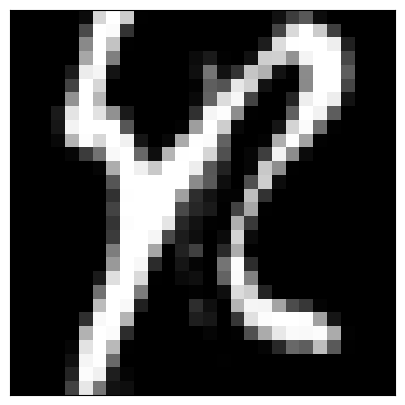

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
if PREPROCESS_DATA or AUGMENT_DATA:
    test_imgs = np.load('../kmnist/kmnist-test-imgs.npz')['arr_0']
    test_labels = np.load('../kmnist/kmnist-test-labels.npz')['arr_0']
    train_imgs = np.load('../kmnist/kmnist-train-imgs.npz')['arr_0']
    train_labels = np.load('../kmnist/kmnist-train-labels.npz')['arr_0']
    print("Number of training samples:", len(train_imgs))
    print("Number of testing samples:", len(test_imgs))
    image = Image.fromarray(train_imgs[9]).convert('RGB')
    plt.figure(figsize=(10, 5))
    plt.imshow(np.array(image, dtype=np.uint8))
    plt.xticks([]), plt.yticks([])
    plt.show()

In [3]:
import csv
if PREPROCESS_DATA or AUGMENT_DATA:
    with open('../kmnist/kmnist_classmap.csv', mode='r') as table:
        reader = csv.reader(table)
        class_to_transcription = dict((rows[0], rows[2]) for rows in reader)
            
    print(class_to_transcription['0'])
    new_train_labels = list()
    for label in train_labels:
        new_train_labels.append(class_to_transcription[str(label)])
        
    print(train_labels[0], new_train_labels[0])
    new_test_labels = list()
    for label in test_labels:
        new_test_labels.append(class_to_transcription[str(label)])
        
    print(new_test_labels[1000])

お
8 れ
ま


In [4]:
from pathlib import Path
if PREPROCESS_DATA or AUGMENT_DATA:
    DATASET_PATH.mkdir(parents=True, exist_ok=True)
    Path('../models').mkdir(parents=True, exist_ok=True)

# Create images and labels from numpy arrays

In [5]:
if PREPROCESS_DATA or AUGMENT_DATA:
    data_dict = {}

    for ind in range(len(train_imgs)):
        savepath = str(DATASET_PATH / (str(ind) +'.png'))
        Image.fromarray(train_imgs[ind]).save(savepath)
        data_dict[savepath] = new_train_labels[ind]
        
    for ind in range(len(test_imgs)):
        savepath = str(DATASET_PATH / (str(ind) +'.png'))
        Image.fromarray(test_imgs[ind]).save(savepath)
        data_dict[savepath] = new_test_labels[ind]
        

In [8]:
from util.augmentation import augment_dataset
from util.data_processing import save_labels

if PREPROCESS_DATA:
    save_labels(data_dict, DATASET_PATH / 'labels.json')
if AUGMENT_DATA:
    augment_dataset(data_dict, 3, 3, 5)
    save_labels(data_dict, DATASET_PATH / 'augmented_labels.json')

# Build lists of images and texts

In [ ]:
import json
from pathlib import Path

with open(str(DATASET_PATH / 'augmented_labels.json'), 'r') as fp:
    data_dict = json.load(fp)

print(f"{len(data_dict.items())} dict elements")

words_files = list(data_dict.items())
print(words_files[0])


240000 dict elements
('preprocessed_data/kmnist/0.png', 'す')


In [ ]:
from util.data_processing import get_words_list

words = get_words_list(words_files)

Building dataset: 100%|██████████| 16000000/16000000 [33:10<00:00, 8036.38it/s]  


Word(file_path='preprocessed_data/text_renderer/images/000000000.jpg', transcription='んですね僕')


# Train test split

In [ ]:
from random import shuffle
import numpy as np

shuffle(words)

train_word_records, test_word_records = np.split(words, [int(len(words)*0.9)])
print(f'Train size: {len(train_word_records)}; Test size: {len(test_word_records)}')

Train size: 14400000; Test size: 1600000


# Build dataset and dataloader

In [ ]:
from util.data_processing import WORDSDataset
from dtrocr.config import DTrOCRConfig

config = DTrOCRConfig(
    # attn_implementation='flash_attention_2'
)
train_data = WORDSDataset(words=train_word_records, config=config)
test_data = WORDSDataset(words=test_word_records, config=config)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
from torch.utils.data import DataLoader
import multiprocessing as mp

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=mp.cpu_count())
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=mp.cpu_count())

# Model

In [ ]:
from util.model import get_model

model = get_model(config, MODEL)

# Training

In [ ]:
from util.model import train

train(model, train_dataloader, test_dataloader, EPOCHS, MODEL, LR, 'KMnist')

# Test

In [ ]:
from dtrocr.model import DTrOCRLMHeadModel
from dtrocr.config import DTrOCRConfig
from dtrocr.processor import DTrOCRProcessor
import torch
torch.save(model.state_dict(), f'../models/{MODEL}.pt')
# model = DTrOCRLMHeadModel(DTrOCRConfig())
model.eval()
model.to('cpu')
test_processor = DTrOCRProcessor(DTrOCRConfig())

In [ ]:
from util.model import test

test(model, train_word_records, 10)